# Example 2: Estimating Water Ages and Travel Times using Phydrus
*Authors: R.A. Collenteur & M. Vremec*

---
This notebook is part of a manuscript that is currently being prepared (spring 2020): 

*R.A. Collenteur, G. Brunetti, M. Vremec & J. Simunek (in preparation) Phydrus: a Python implementation of the Hydrus-1D model.*

---
In this Notebook the model constructed in the previous example is extended with solute transport module to 

1. calculate water ages of the water draining from the soil column. 
2. calculate the travel time distributions for each precipiation event
---
### 1. Import the Pydrus package

In [1]:
# Import the necessary modules
import os

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import phydrus as ps

### 2. Create the basic model
In the following code block we recreate the model developed in Example 1. We add solute transport to the model to calculate the water ages.

In [2]:
#Folder where the Hydrus files are to be stored
ws = "output"
exe = '/opt/hydrus1d/bin/hydrus'

# Create model
ml = ps.Model(exe_name=exe, ws_name=ws, name="model",
              mass_units="mmol", time_unit="days", length_unit="cm")

ml.add_time_info(tinit=0, tmax=730)
ml.add_waterflow(top_bc=3, bot_bc=4)

# Add the process solute transport
ml.add_solute_transport(lupw=True)

# Add materials
m = ml.get_empty_material_df(n=2)
m.loc[0:2] = [[0.0, 0.3382, 0.0111, 1.4737, 13, 0.5, 1.5, 30.0, 1, 0],
              [0.0, 0.3579, 0.0145, 1.5234, 50, 0.5, 1.5, 30.0, 1, 0]]
ml.add_material(m)

# Define loop for potential root water uptake distribution proposed by Hoffman and Van Genuchten
def z_loop(z, r1=10, r2=20):
    if z > -r1:
        return 1
    elif z < -(r1 + r2):
        return 0
    else:
        return(z + (r1 + r2)) / r2

bottom = [-30, -100]  # Depth of the soil column
nodes = 150  # Dictretize into n nodes
ihead = -500  # Determine initial pressure head

profile = ps.create_profile(bot=bottom, dx=1, h=ihead, conc=1e-10, mat=[1,2], lay=[1,2])
profile["Beta"] = profile.apply(lambda row: z_loop(row["x"]), axis=1)
ml.add_profile(profile)

#ml.add_root_uptake(model=0, crootmax=100, omegac=0, p2h=-1500, p2l=-1500, poptm=[-25, -25])

ml.add_obs_nodes([-30, -60])

### 3. Add materials & Solutes

In [3]:
sol = ml.get_empty_solute_df()
sol.loc[:, "beta"] = 1.0
ml.add_solute(sol,difw=1e-9)

### 4. Add atmosphere boundary conditions

In [4]:
atm = pd.read_csv("../data/atmosphere.csv", index_col=0)
atm["cBot"] = 0.0
atm["cTop"] = 0.0
atm.loc[0, "cTop"] = 1.0
ml.add_atmospheric_bc(atm, hcrits=0)

In [5]:
# Write the input and check if the model simulates
ml.write_input()
ml.simulate()

INFO: Successfully wrote output/SELECTOR.IN
INFO: Successfully wrote output/PROFILE.DAT
INFO: Successfully wrote output/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


CompletedProcess(args=['/opt/hydrus1d/bin/hydrus', 'output', '-1'], returncode=0)

### 5. Calculate the water ages
In the following code block we calculate the water ages for the water draining from the soil column. To do this, virtual tracers are used to track the flow of water through the soil. The model is run for each precipitation event with a solute concentration of 1 is given to each precipitation event, while the concentration is set to zero for the other events. This requires us to run the model N number of times, where N is the number of precipitation events. This can easily be done using a Python for-loop.

In [6]:
data = {}
data2 = {}

for i in atm.loc[:365].loc[atm.loc[:365, "Prec"] > 0].index:
    try:
        ml.atmosphere.loc[:, "cTop"] = 0
        ml.atmosphere.loc[i, "cTop"] = 1
        ml.write_atmosphere(verbose=True);
        ml.simulate()
        s = ml.read_solutes()
        data[i] = s.loc[:, "cvBot"]
        data2[i] = s.loc[:, "cBot"]
    except:
        # Just to check if the model fails
        print(i)

0
1
18
21
22
23
25
36
37
39
42
43
45
55
56
58
60
66
77
78
81
82
83
84
89
90
91
92
93
96
114
118
123
124
125
127
128
131
134
136
139
140
141
142
143
146
147
148
149
154
155
156
157
158
162
166
168
173
176
177
178
180
183
184
185
187
188
189
190
192
204
207
208
209
210
214
218
220
221
222
223
224
228
229
231
233
234
236
239
240
241
243
245
246
247
248
249
253
260
269
270
277
278
290
291
292
293
294
295
296
298
300
301
302
312
314
321
322
328
335
336
340
341
342
343
345
346
348
349
350


### 6. Preprocess the results

In [7]:
q = -ml.read_tlevel()["vBot"]
df = -pd.DataFrame.from_dict(data, orient="columns")
df = df.dropna(axis=1)

df2 = pd.DataFrame.from_dict(data2, orient="columns")
df2.index = df2.index.astype(float).astype(int)

### 7. Make plot of water ages in recharge flux

/var/folders/01/3173b8215hv1b7syv5mv_mlm0000gn/T/ipykernel_92917/1602345871.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


IndexError: index 0 is out of bounds for axis 0 with size 0

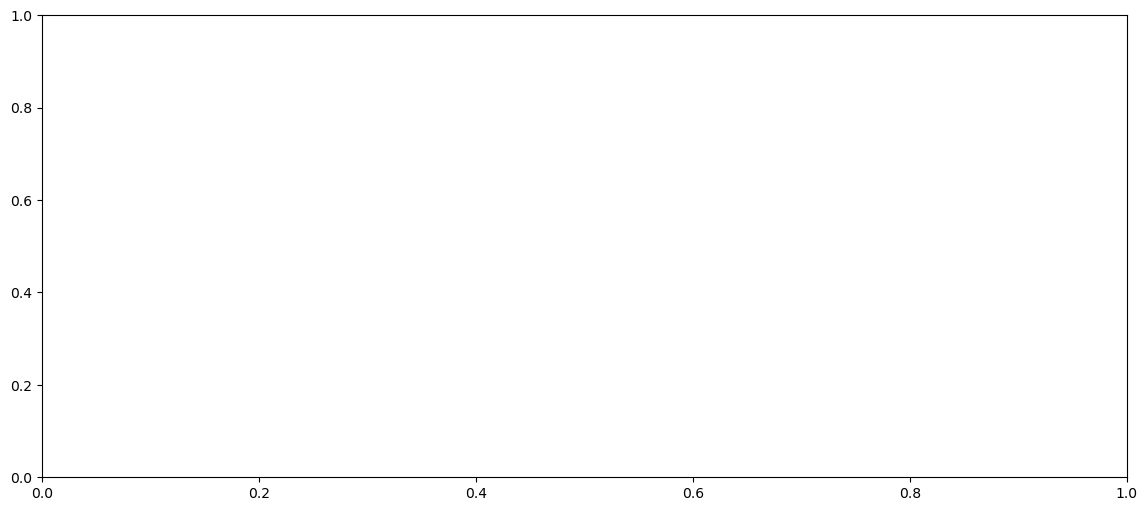

In [8]:
fig, ax1 = plt.subplots(1,1, figsize=(14,6), sharex=True)

cmap = plt.cm.get_cmap('viridis')
cmap.set_under('w')
cmap.set_over("w")
a = cmap(np.linspace(0, 1, 365))

# Plot the recharge and water age
ax1.stackplot(df.index, df.values.T, edgecolor="", linewidth=0, colors=a[df.columns.astype(float).astype(int)]);
q.plot(ax=ax1, color="k")
ax1.set_xlim(0)
ax1.set_ylim(0, 1.2)
ax1.set_yticks([0, 0.5, 1])
plt.xlabel("Time [Days]")
plt.ylabel("Drainage [cm/day]")

# Plot the Precipitation data
ax2 = ax1.twinx()
(-atm.Prec.iloc[:365]).plot.bar(ax=ax2, color=a,edgecolor="k", width=2)
#(-atm.Prec.iloc[365:]).plot.bar(ax=ax2, sharex=ax1, color="w", edgecolor="k", width=2)
ax2.bar(atm.Prec.iloc[365:].index, -atm.Prec.iloc[365:], color="w", edgecolor="k", width=1.5)
ax2.set_ylabel("Precipitation [cm/day]")
ax2.set_ylim(-16, 0)
ax2.set_yticks([0,-2,-4])
ax2.set_xlim(0,550)
plt.xticks([0, 180, 365, 550], ["Jan-07", "Jul-07", "Jan-08", "Jul-08"])

# Plot Colorbar
norm  = mpl.colors.Normalize(vmin=0, vmax=365)
axl = fig.add_axes([0.54, 0.70, 0.3, 0.02])
cb1 = mpl.colorbar.ColorbarBase(axl, cmap=cmap, norm=norm, orientation='horizontal', extend="both", 
                                ticks=[0,365], label="Date precipitation event [Days]")
cb1.ax.set_xticklabels(["Jan\n07", "Jan\n08"]);

#plt.savefig("../../figures/water_ages.eps", bbox_inches="tight", dpi=300)

### 8. Make a plot of the Travel Time Distributions

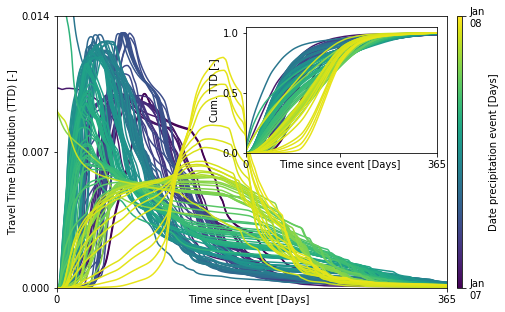

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(7, 5))

left, bottom, width, height = [0.50, 0.5, 0.38, 0.35]
ax2 = fig.add_axes([left, bottom, width, height])

for i in df2.columns:
    d = df2.loc[i:, i]
    d = d / d.cumsum().iloc[-1]
    d.index = range(len(d.index))
    d.plot(color=[a[i]], ax=ax)
    
    d = d.cumsum()/d.cumsum().iloc[-1]
    d.plot(color=[a[i]], ax=ax2)

ax.set_xticks([0, 180, 365])
ax.set_xticklabels(["0", "Time since event [Days]", "365"])
ax.set_xlim(0, 365)
ax.set_ylim(0, 0.014);
ax.set_yticks([0, 0.007, 0.014])
ax.set_ylabel("Travel Time Distribution (TTD) [-]")

ax2.set_xlim(0, 365)
ax2.set_ylim(0);
ax2.set_xticks([0, 180, 365])
ax2.set_xticklabels(["0", "Time since event [Days]", "365"])
ax2.set_yticks([0, 0.5, 1])
ax2.set_ylabel("Cum. TTD [-]")

# Plot Colorbar
axl = fig.add_axes([0.92, 0.125, 0.01, 0.755])
norm  = mpl.colors.Normalize(vmin=0, vmax=365)
cb1 = mpl.colorbar.ColorbarBase(axl, cmap=cmap, norm=norm, orientation='vertical',
                                ticks=[0,365], label="Date precipitation event [Days]")
cb1.ax.set_yticklabels(["Jan\n07", "Jan\n08"]);

#plt.savefig("../../figures/mttd_curves.eps", bbox_inches="tight")